Warm Season SOMs: Defined as May-Sept

In [108]:
#Necessary packages to load data
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from minisom import MiniSom
import sklearn_som
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from sammon import sammon

Load in the data

In [109]:
base_dir =r"D:\ERA 5 Data\ERA5_Camden"

In [110]:
var_config = {
    # Original ERA5 variables
    
    "temp": {
        "folder": "Temp",
        "pattern": "era5_2mtemp__*.nc"
    },
    
    "u10": {
        "folder": "U Vector Wind",
        "pattern": "era5_uvector_*.nc"
    },
    
    "v10": {
        "folder": "V Vector Wind",
        "pattern": "era5_vvector_*.nc"
    },
    
    "sp": {
        "folder": "Surface Pressure",
        "pattern": "era5_sp__*.nc"
    },
    
    "dp": {
        "folder": "Dewpoint Temp",
        "pattern": "era5_2m_dew_temp__*.nc"
    },
    
    "k": {
        "folder": "K Index",
        "pattern": "era5_k_index_temp__*.nc"
    },
    
    "sol": {
        "folder": "Sol Rad",
        "pattern": "era5_surface_net_solar_radiation__*.nc"
    },

    "gph": {
        "folder": "Geopotential_500hPa",
        "pattern": "era5_geopotential_500hPa__*.nc"
    },
    # Calculated variables
    "rh": {
        "folder": "Relative Humidity",
        "pattern": "relative_humidity_*.nc"
    },

    "ws": {
        "folder": "Wind Speed",
        "pattern": "wind_speed_*.nc"
    },

    "hi": {
        "folder": "Heat Index",
        "pattern": "heat_index_*.nc"
    },

    "wb": {
        "folder": "Wet Bulb Temp",
        "pattern": "wet_bulb_temperature_*.nc"
    },
}

In [111]:
#Combine each year
def load_variable(var_name):
    config = var_config[var_name]

    path = os.path.join(base_dir, config["folder"], config["pattern"])

    ds = xr.open_mfdataset(
        path,
        combine="by_coords",
        parallel=False   # IMPORTANT (Windows stability)
    )

    return ds

In [113]:
#To look at other variables raw data change what is in "" to any of the variables in block 3
ds = load_variable("gph")

print(ds)               # full structure
print(ds.variables)     # variables
print(ds.dims)          # dimensions
print(ds.attrs)         # metadata

<xarray.Dataset> Size: 12GB
Dimensions:         (valid_time: 192864, pressure_level: 1, latitude: 97,
                     longitude: 161)
Coordinates:
    number          int64 8B 0
  * valid_time      (valid_time) datetime64[ns] 2MB 2004-01-01 ... 2025-12-31...
  * pressure_level  (pressure_level) float64 8B 500.0
  * latitude        (latitude) float64 776B 54.0 53.75 53.5 ... 30.5 30.25 30.0
  * longitude       (longitude) float64 1kB -100.0 -99.75 -99.5 ... -60.25 -60.0
    expver          (valid_time) <U4 3MB dask.array<chunksize=(8784,), meta=np.ndarray>
Data variables:
    z               (valid_time, pressure_level, latitude, longitude) float32 12GB dask.array<chunksize=(2928, 1, 33, 54), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    

In [114]:
#Enter in the actual data variable title from the ERA5 data
ds.z

<xarray.DataArray 'z' (valid_time: 192864, pressure_level: 1, latitude: 97,
                       longitude: 161)> Size: 12GB
dask.array<concatenate, shape=(192864, 1, 97, 161), dtype=float32, chunksize=(2928, 1, 33, 54), chunktype=numpy.ndarray>
Coordinates:
    number          int64 8B 0
  * valid_time      (valid_time) datetime64[ns] 2MB 2004-01-01 ... 2025-12-31...
  * pressure_level  (pressure_level) float64 8B 500.0
  * latitude        (latitude) float64 776B 54.0 53.75 53.5 ... 30.5 30.25 30.0
  * longitude       (longitude) float64 1kB -100.0 -99.75 -99.5 ... -60.25 -60.0
    expver          (valid_time) <U4 3MB dask.array<chunksize=(8784,), meta=np.ndarray>
Attributes: (12/31)
    GRIB_paramId:                             129
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      15617
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           z
    GRIB_totalNumber:                         0
    GRIB_units:                               m**2 s**-2
    long_name:                                Geopotential
    units:                                    m**2 s**-2
    standard_name:                            geopotential

In [115]:
#Set city of interest lat and lon
camden_lat = 39.9259
camden_lon = -75.1196

<class 'xarray.core.dataarray.DataArray'>
<xarray.DataArray 'z' (valid_time: 192864, pressure_level: 1)> Size: 771kB
dask.array<getitem, shape=(192864, 1), dtype=float32, chunksize=(2928, 1), chunktype=numpy.ndarray>
Coordinates:
    number          int64 8B 0
  * valid_time      (valid_time) datetime64[ns] 2MB 2004-01-01 ... 2025-12-31...
  * pressure_level  (pressure_level) float64 8B 500.0
    latitude        float64 8B 40.0
    longitude       float64 8B -75.0
    expver          (valid_time) <U4 3MB dask.array<chunksize=(8784,), meta=np.ndarray>
Attributes: (12/31)
    GRIB_paramId:                             129
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      15617
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           z
    GRIB_tot

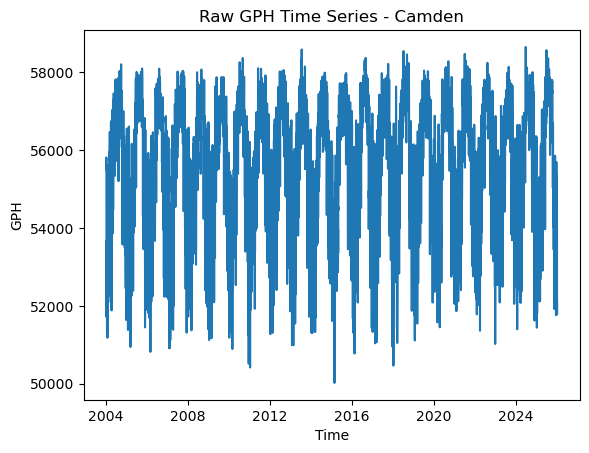

In [116]:
ds = load_variable("gph") #use variable title from block 3

# Select nearest grid cell and variable -- use data varaible title
camden = ds["z"].sel(
    latitude=camden_lat,
    longitude=camden_lon,
    method="nearest"
)

print(type(camden))  # should now be DataArray
print(camden)

camden_daily = camden.resample(valid_time="1D").mean()

df_camden = camden_daily.to_dataframe(name="gph").reset_index()
df_camden = df_camden.set_index("valid_time")

#visualize the data
plt.figure()
plt.plot(df_camden.index, df_camden["gph"])
plt.xlabel("Time")
plt.ylabel("GPH")
plt.title("Raw GPH Time Series - Camden")
plt.show()

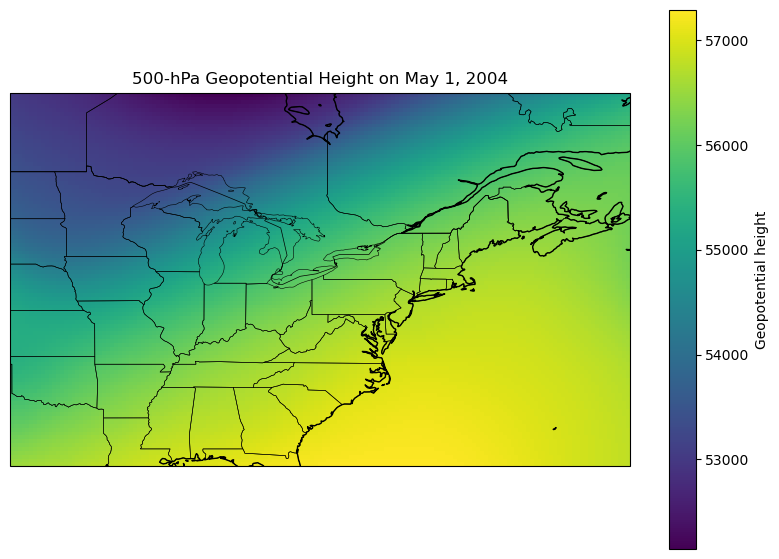

In [117]:
fig, ax = plt.subplots(
    figsize=(10, 7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ds["z"].resample(valid_time="1D").mean().sel(valid_time="2004-05-01").plot(
    ax=ax,
    x="longitude",
    y="latitude",
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    cbar_kwargs={"label": "Geopotential height"}
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.4)
ax.set_title(f"500-hPa Geopotential Height on May 1, 2004")

plt.show()

Aggregate to daily for just the warm season: Defined as May to September

In [118]:
# use variable titles from block 3: "u10", "v10" etc **ORDER MATTERS**
vars_to_use = [
    "gph"
]

#Load datasets
datasets = {var: load_variable(var) for var in vars_to_use}

# Create an empty 2D (Rows & Columns) array to store the subset (May–Sept) + daily max
processed_datasets = {}

# Create a loop to iterate through the datasets and process them
for name, ds in datasets.items():

    var = next(iter(ds.data_vars))

    # May-Sept only with Boolean Mask
    ds_warm = ds.where(
        (ds.valid_time.dt.month >= 5) &
        (ds.valid_time.dt.month <= 9),
        drop=True
    )

    print(name, "after subset:", len(ds_warm.valid_time))

    # Daily aggregation
    if name in ["temp"]:
        ds_daily = (
            ds_warm
            .resample(valid_time="24h")
            .max()
        )

    elif name in ["gph"]:
        ds_daily = (
            ds_warm
            .resample(valid_time="24h")
            .mean()
        )

    ds_daily = ds_daily.dropna(dim="valid_time", how="all")

    processed_datasets[name] = ds_daily

    print(name, "after daily:", len(ds_daily.valid_time))

gph after subset: 80784
gph after daily: 3366


In [119]:
for name, ds in processed_datasets.items():
    print(name, len(ds.valid_time))

print(datasets.keys())
for name, ds in datasets.items():
    print(name, list(ds.data_vars))

gph 3366
dict_keys(['gph'])
gph ['z']


In [122]:
print(ds_norm[var].dims)
print(ds_norm[var].pressure_level.values)

('valid_time', 'pressure_level', 'latitude', 'longitude')
[500.]


V1 Normalization: Z-score normalization within each group: standardizes each variable by day-of-year 

daily anomaly=  (daily value−DOY mean)/ DOY standard deviation

In [123]:
#Normalize each variable separately  -- (valid_time, lat, lon)
normalized_datasets = {}

#Flatten each variable separately -- (valid_time, space)
flattened_data = {}

for name, ds in processed_datasets.items():
    var = next(iter(ds.data_vars))

    #groups all observations that share the same calendar day across years
    group = ds.groupby("valid_time.dayofyear")

    #Z-score normalization within each group: standardizes each variable by day-of-year 
    ds_norm = group.map(
        lambda x: (
            (x - x.mean("valid_time")) /
            #handles cases where the standard deviation is zero by replacing it with 1 to avoid division by zero errors
            (lambda s: s.where(s != 0, 1))(x.std("valid_time"))
        )
    )

    normalized_datasets[name] = ds_norm
# .squeeze("pressure_level", drop=True) removes the pressure_level dimension since it contains only one value
#If switching from pressure level to surface variables, remove the squeeze line since surface variables do not have a pressure level dimension.
    flat = (
    ds_norm[var]
    .squeeze("pressure_level", drop=True)
    .stack(space=("latitude", "longitude"))
    .transpose("valid_time", "space")
)

    flattened_data[name] = flat

    print(name, "done:", flat.shape)

gph done: (3366, 15617)


In [124]:
#Check for NANs
for name, ds in normalized_datasets.items():
    print(name, ds.isnull().to_array().sum().values)

gph 0


V2 Normalization: Climatological Normalization

At this point the datasets have been aggregated for daily data, noralized (per variable, against the day), and then flattened (per variable)

So after flattening, each variable is:

shape: time × space

So a single variable is:

rows = valid_time

columns = latitude/longitude grid cells

SOM Model Set Up

        """Initializes a Self Organizing Maps.

        A rule of thumb to set the size of the grid for a dimensionality
        reduction task is that it should contain 5*sqrt(N) neurons
        where N is the number of samples in the dataset to analyze.

        E.g. if your dataset has 150 samples, 5*sqrt(150) = 61.23
        hence a map 8-by-8 should perform well.

        Parameters
        ----------
        x : int
            x dimension of the SOM.

        y : int
            y dimension of the SOM.

        input_len : int
            Number of the elements of the vectors in input.

        sigma : float, optional (default=1)
            Spread of the neighborhood function.

            Needs to be adequate to the dimensions of the map
            and the neighborhood function. In some cases it
            helps to set sigma as sqrt(x^2 +y^2).

        learning_rate : float, optional (default=0.5)
            Initial learning rate.

            Adequate values are dependent on the data used for training.

            By default, at the iteration t, we have:
                learning_rate(t) = learning_rate / (1 + t * (100 / max_iter))

        decay_function : string or callable, optional
        (default='asymptotic_decay')
            Function that reduces learning_rate at each iteration.
            Possible values: 'inverse_decay_to_zero', 'linear_decay_to_zero',
                             'asymptotic_decay' or callable

            If a custom decay function using a callable
            it will need to to take in input
            three parameters in the following order:

            1. learning rate
            2. current iteration
            3. maximum number of iterations allowed

            Note that if a lambda function is used to define the decay
            MiniSom will not be pickable anymore.

        neighborhood_function : string, optional (default='gaussian')
            Function that weights the neighborhood of a position in the map.
            Possible values: 'gaussian', 'mexican_hat', 'bubble', 'triangle'

        topology : string, optional (default='rectangular')
            Topology of the map.
            Possible values: 'rectangular', 'hexagonal'

        activation_distance : string, callable optional (default='euclidean')
            Distance used to activate the map.
            Possible values: 'euclidean', 'cosine', 'manhattan', 'chebyshev'

            Example of callable that can be passed:

            def euclidean(x, w):
                return linalg.norm(subtract(x, w), axis=-1)

        random_seed : int, optional (default=None)
            Random seed to use.

        sigma_decay_function : string, optional
        (default='asymptotic_decay')
            Function that reduces sigma at each iteration.
            Possible values: 'inverse_decay_to_one', 'linear_decay_to_one',
                             'asymptotic_decay'

            The default function is:
                sigma(t) = sigma / (1 + (t * (sigma - 1) / max_iter))

In [125]:
#Concatenate all flattened variables into a single DataArray along the 'space' dimension
#concatenation stacks data along one axis
X = xr.concat(list(flattened_data.values()), dim="space")

In [126]:
print(X.dims)

('valid_time', 'space')


In [127]:
print(X.shape)

(3366, 15617)


In [128]:
#MiniSom expects a2D numeric array and does operations like: X[row, :]
X = X.to_numpy()


Gibson et al (2017) training SOM-C process: 2 phase trainig

Phase 1: iterations 0–2500

Neighborhood radius decreases linearly from 5 to 1.
Learning rate decreases from 0.05 toward 0.

Phase 2: iterations 2500–5000

Neighborhood radius remains fixed at 1.
Learning rate continues decreasing linearly until 0.


Other parameters are fixed:
1. A total of 5000 iterations
2. Hexagonal grid
3. Euclidean distance
4. Random initialization

In [151]:
# define 2 phase learning rate function
def linear_learning_rate_phase1(learning_rate, current_iteration, max_iter):
    # iterations 0–2500
    return learning_rate * (1 - current_iteration / 5000)


def linear_learning_rate_phase2(learning_rate, current_iteration, max_iter):
    # iterations 2500–5000
    return learning_rate * (1 - (current_iteration + 2500) / 5000)

# use the now Numpy array "X" for training the SOM
# general rule iterations ≈ 10 × number_of_samples
som = MiniSom(
    x=5,
    y=6,
    input_len=X.shape[1],
    sigma=5,        #np.sqrt(5**2 + 6**2)
    learning_rate=0.05,
    sigma_decay_function= "linear_decay_to_one",
    decay_function= linear_learning_rate_phase1,    
    neighborhood_function='gaussian', 
    topology='hexagonal',
    activation_distance='euclidean',
    random_seed=42
)

som.random_weights_init(X)

# Phase 1: radius decreases from 5 to 1 over 2500 iterations
som.train_random(X, 2500, verbose=True)

# Phase 2: hold radius at 1
som._sigma = 1
som._sigma_decay_function = lambda sigma, current_iteration, max_iter: 1
som._learning_rate_decay_function = linear_learning_rate_phase2

# Continue training for another 2500 iterations
som.train_random(X, 2500, verbose=True)


 [ 2500 / 2500 ] 100% - 0:00:00 left 
 quantization error: 90.41983275238374
 [ 2500 / 2500 ] 100% - 0:00:00 left 
 quantization error: 85.63616622107523


In [152]:
QE = som.quantization_error(X)
print(QE)

TE = som.topographic_error(X)
print(TE)

85.63616622107523
0.048128342245989275


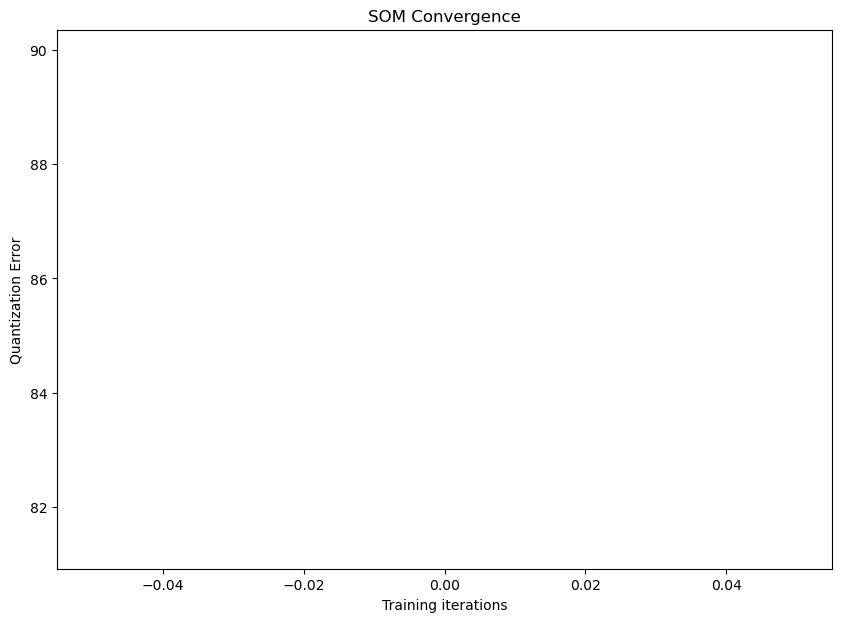

In [153]:
# Plot the quantization error over iterations to assess convergence 
plt.figure(figsize=(10, 7))
plt.plot(som.quantization_error(X))
plt.xlabel("Training iterations")
plt.ylabel("Quantization Error")
plt.title("SOM Convergence")
plt.show()

In [154]:
# Get the centers of the SOM nodes
#som.get_weights() returns the SOM unit weights. SOM weights are the representative vectors for each node in the SOM grid, capturing the patterns learned from the input data.
#SOM unit weights are stored in a 3D array with dimensions (x, y, input_len), where x and y are the dimensions of the SOM grid, and input_len is the number of features in the input data. Each weight vector represents the learned pattern for a specific node in the SOM grid.
#reshape(-1, X.shape[1]) flattens the 3D array into a 2D array where each row corresponds to a SOM node and each column corresponds to a feature in the input data. This allows for easier analysis and visualization of the learned patterns.
som_centers = som.get_weights().reshape(-1, X.shape[1])
print(som_centers)

#Get the labels for each input data point based on the trained SOM
# Loop over each row of X to find the winning node (Best Matching Unit) for each input vector. The som.winner(x) method returns the coordinates (row, col) of the winning node in the SOM grid for the input vector x.
som_labels = np.array([som.winner(x) for x in X]) #This gives (row,col)
print(som_labels[:10]) 

#Flatten the 2D coordinates of the winning nodes into a 1D array of labels. This is done by converting the (row, col) coordinates into a single index using the formula: index = row * number_of_columns + col. This allows for easier analysis and visualization of the SOM results.
# som.get_weights().shape[1] is the number of columns in the map, which is y
som_labels_flat = np.array([r * som.get_weights().shape[1] + c for r, c in som_labels])
print(som_labels_flat[:10])

[[-0.00684823 -0.01553099 -0.0243855  ... -0.16548143 -0.15987385
  -0.15448593]
 [-0.23057905 -0.24450783 -0.25854495 ... -0.03462656 -0.03237339
  -0.03028931]
 [-0.30812098 -0.32016546 -0.33233061 ...  0.07352814  0.07341337
   0.07337448]
 ...
 [ 0.1758766   0.18318748  0.19040865 ... -0.10806389 -0.11173189
  -0.11526542]
 [ 0.04719489  0.05546051  0.06378967 ... -0.01763221 -0.02415834
  -0.03070296]
 [-0.17839218 -0.17234978 -0.16613604 ...  0.06457355  0.05635733
   0.0480884 ]]
[[1 5]
 [0 5]
 [0 5]
 [0 2]
 [1 2]
 [3 3]
 [3 3]
 [3 3]
 [3 3]
 [3 5]]
[11  5  5  2  8 21 21 21 21 23]


A look at SOM Nodes

In [155]:
# Create DataFrame mapping time → node
times = pd.to_datetime(ds_daily['valid_time'].values)  # shape (n_time,)
df_som = pd.DataFrame({
    'time': times,
    'node': som_labels_flat
})

# Set 'time' as the index
df_som.set_index('time', inplace=True)

# Lookup SOM node at specific time 
query_time = pd.to_datetime("2026-05-19")
node_number = df_som.loc[query_time, 'node']
print(f"SOM node at {query_time}: {node_number}")

# Lookup a range of times
query_range = pd.date_range("2026-05-18", "2026-05-24", freq='D')
nodes_range = df_som.loc[query_range]
print(nodes_range.head(10))

KeyError: Timestamp('2026-05-19 00:00:00')

node     0   1   2   3   4   5   6   7   8   9   ...  20  21  22  23  24  25  \
time                                             ...                           
2004-05   1   2   2   1   0   2   0   1   1   2  ...   0   4   0   8   0   0   
2004-06   1   5   2   2   0   1   0   1   2   1  ...   0   1   1   1   0   0   
2004-07   7   0   0   4   1   6   4   0   0   0  ...   1   0   0   0   1   1   
2004-08   0   6   1   4   0   6   6   0   0   0  ...   0   0   0   0   0   0   
2004-09   0   0   0   0   2   6   0   0   0   0  ...   1   2   2   0   0   0   

node     26  27  28  29  
time                     
2004-05   0   0   0   2  
2004-06   0   0   0   1  
2004-07   1   0   0   0  
2004-08   0   0   0   0  
2004-09   5   2   1   3  

[5 rows x 30 columns]


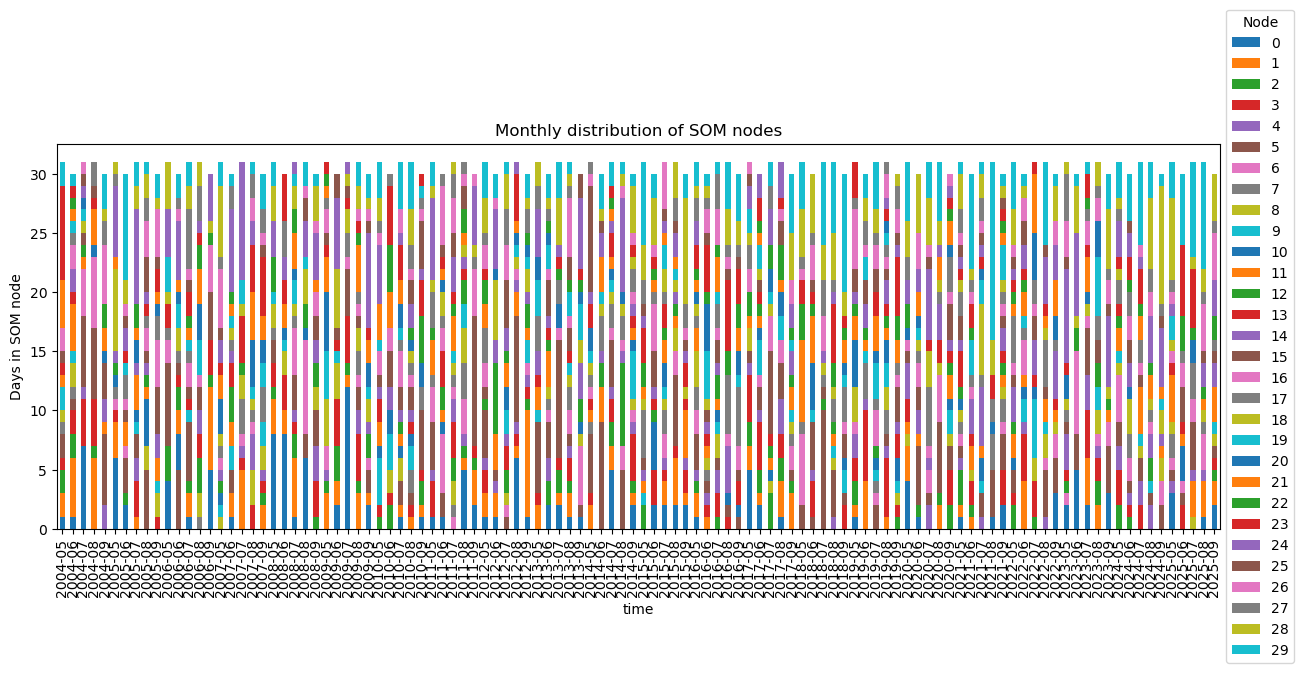

In [156]:
#Aggrgate nodes into months
# DAILY counts of each SOM node
daily_counts = df_som.groupby([df_som.index.date, 'node']).size().unstack(fill_value=0)

# MONTHLY counts of each SOM node
monthly_counts = df_som.groupby([df_som.index.to_period('M'), 'node']).size().unstack(fill_value=0)
print(monthly_counts.head())

# Plot monthly distribution 
monthly_counts.plot(kind='bar', stacked=True, figsize=(15,5))
plt.ylabel("Days in SOM node")
plt.title("Monthly distribution of SOM nodes")
plt.legend(title="Node", loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [157]:
#Find the exact days in a node of interest
#Identify node of interest
node_id = 8

times_in_node = df_som[df_som['node'] == node_id]

print(times_in_node.head())
print(f"\nTotal days in node {node_id}:", len(times_in_node))

dates_som = df_som.index[df_som['node'] == node_id].date

unique_days = np.unique(dates_som)
print(len(unique_days))

            node
time            
2004-05-05     8
2004-06-29     8
2004-06-30     8
2005-08-18     8
2005-08-22     8

Total days in node 8: 95
95


In [158]:
#HIT Map: the percentage of days in each month that fall into the node of interest
# Total days in the dataset
total_days = len(df_som)

# Days per node
node_dates = (
    df_som
    .groupby('node') 
    .apply(lambda x: x.index.date, include_groups=False) #x is a small DataFrame of only that cluster \ x.index = all timestamps in that cluster \.date removes the hour
)
# compute unique day counts,
days_per_node = (
    df_som
    .assign(date=df_som.index.date)
    .groupby('node')['date']
    .nunique()
)

# Percent of time
percent = (days_per_node / total_days) * 100

# Combine into one table
node_summary = pd.DataFrame({
    'Days': days_per_node,
    'Percent': percent.round(2)
})

print(node_summary)

      Days  Percent
node               
0      148     4.40
1      133     3.95
2       72     2.14
3      135     4.01
4       60     1.78
5      250     7.43
6      116     3.45
7       52     1.54
8       95     2.82
9       74     2.20
10      68     2.02
11     113     3.36
12      92     2.73
13      74     2.20
14     108     3.21
15     102     3.03
16      95     2.82
17     123     3.65
18      87     2.58
19      84     2.50
20      69     2.05
21     108     3.21
22      69     2.05
23     132     3.92
24     218     6.48
25      64     1.90
26     117     3.48
27      88     2.61
28     184     5.47
29     236     7.01


[[148 133  72 135  60 250]
 [116  52  95  74  68 113]
 [ 92  74 108 102  95 123]
 [ 87  84  69 108  69 132]
 [218  64 117  88 184 236]]


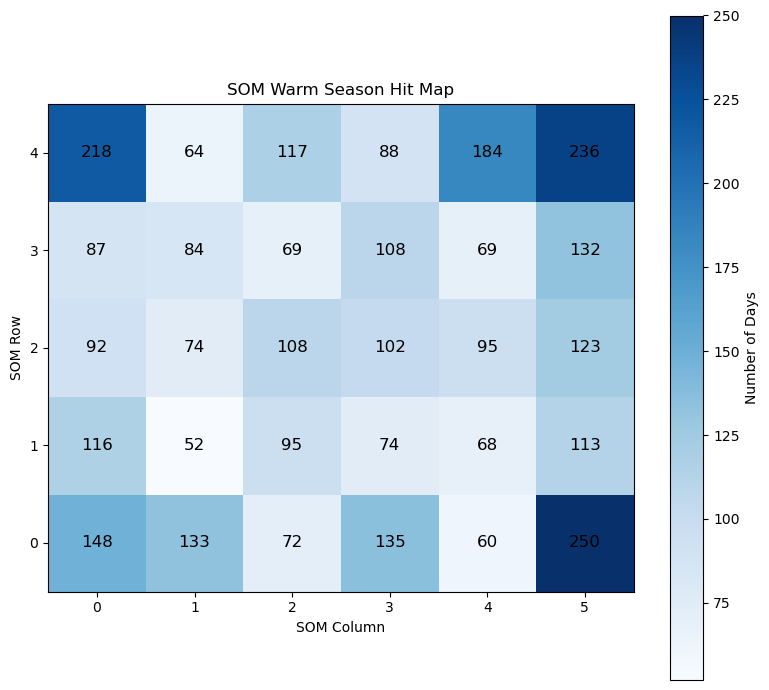

In [159]:
n_rows, n_cols = 5, 6 #Edit to the correct shape of the SOM grid

# Number of nodes
n_nodes = n_rows * n_cols

# Count observations assigned to each SOM node
hit_counts = pd.Series(som_labels_flat).value_counts()

# Make sure every node is included, even if it has 0 hits
hit_counts = hit_counts.reindex(
    range(n_nodes),
    fill_value=0
)

# Reshape into SOM grid
hit_map = hit_counts.values.reshape(n_rows, n_cols)

print(hit_map)
plt.figure(figsize=(8, 7))

plt.imshow(hit_map, origin="lower", cmap="Blues", interpolation="nearest")

plt.colorbar(label="Number of Days")

plt.xticks(range(n_cols))
plt.yticks(range(n_rows))

plt.xlabel("SOM Column")
plt.ylabel("SOM Row")
plt.title("SOM Warm Season Hit Map")

# Add number of observations to each node
for i in range(n_rows):
    for j in range(n_cols):
        plt.text(
            j,
            i,
            hit_map[i, j],
            ha="center",
            va="center",
            fontsize=12
        )

plt.tight_layout()
plt.show()

In [ ]:
"""Perform Sammon mapping on dataset x
    y = sammon(x) applies the Sammon nonlinear mapping procedure on
    multivariate data x, where each row represents a pattern and each column
    represents a feature.  On completion, y contains the corresponding
    co-ordinates of each point on the map.  By default, a two-dimensional
    map is created.  
    
    Note if x contains any duplicated rows, SAMMON will
    fail (ungracefully). 
    
    [y,E] = sammon(x) also returns the value of the cost function in E (i.e.
    the stress of the mapping).
    An N-dimensional output map is generated by y = sammon(x,n) .
    A set of optimisation options can be specified using optional
    arguments, y = sammon(x,n,[OPTS]):
       maxiter        - maximum number of iterations
       tolfun         - relative tolerance on objective function
       maxhalves      - maximum number of step halvings
       input          - {'raw','distance'} if set to 'distance', X is 
                        interpreted as a matrix of pairwise distances.
       display        - 0 to 2. 0 least verbose, 2 max verbose.
       init           - {'pca', 'cmdscale', random', 'default'}
                        default is 'pca' if input is 'raw', 
                        'msdcale' if input is 'distance'
    """


"Perform Sammon mapping on dataset x\n    y = sammon(x) applies the Sammon nonlinear mapping procedure on\n    multivariate data x, where each row represents a pattern and each column\n    represents a feature.  On completion, y contains the corresponding\n    co-ordinates of each point on the map.  By default, a two-dimensional\n    map is created.  Note if x contains any duplicated rows, SAMMON will\n    fail (ungracefully). \n    [y,E] = sammon(x) also returns the value of the cost function in E (i.e.\n    the stress of the mapping).\n    An N-dimensional output map is generated by y = sammon(x,n) .\n    A set of optimisation options can be specified using optional\n    arguments, y = sammon(x,n,[OPTS]):\n       maxiter        - maximum number of iterations\n       tolfun         - relative tolerance on objective function\n       maxhalves      - maximum number of step halvings\n       input          - {'raw','distance'} if set to 'distance', X is \n                        interpret

Following this tutorial: https://github.com/taliakurtz/MiniSOM_tutorial/blob/main/MiniSOM_Tutorial_Step_2.ipynb

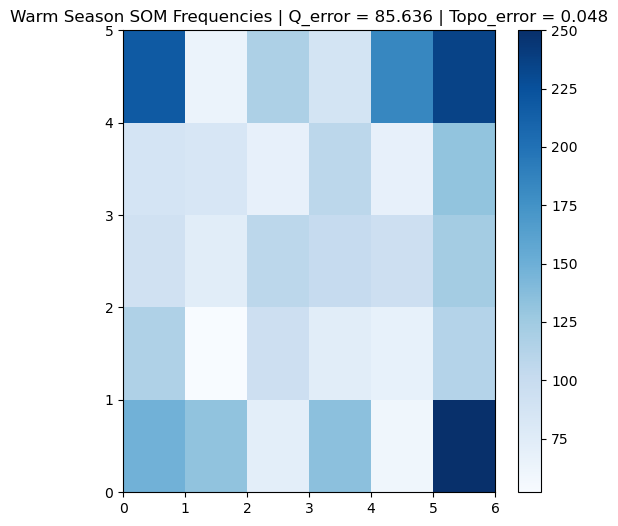

In [160]:
# Quantization Error and Topographic Error Figure
# Quantization error in a Self-Organizing Map (SOM) is the average distance between each input data point and the weight vector of its closest matching neuron (best matching unit).
# Quantization Error measures how much information or precision is lost when continuous input data is mapped onto a discrete grid of neurons. A lower quantization error indicates that the SOM has learned to represent the input data more accurately, while a higher quantization error suggests that the SOM may not be capturing the underlying structure of the data effectively.
# Topographic Error measures how well the SOM preserves the topological relationships of the input data in the low-dimensional map. It quantifies the proportion of input data points for which the first and second best matching units are not adjacent in the SOM grid.
# Topographic Error  measures how well a map preserves the neighborhood relationships of the original input data
frequencies = som.activation_response(X)
q_error = round(som.quantization_error(X), 3)
topo_error = round(som.topographic_error(X), 3)
plt.figure(figsize=(6, 6))
cs = plt.pcolormesh(frequencies, cmap="Blues")
plt.title(f"Warm Season SOM Frequencies | Q_error = {q_error} | Topo_error = {topo_error}")
plt.colorbar(cs)
plt.show()

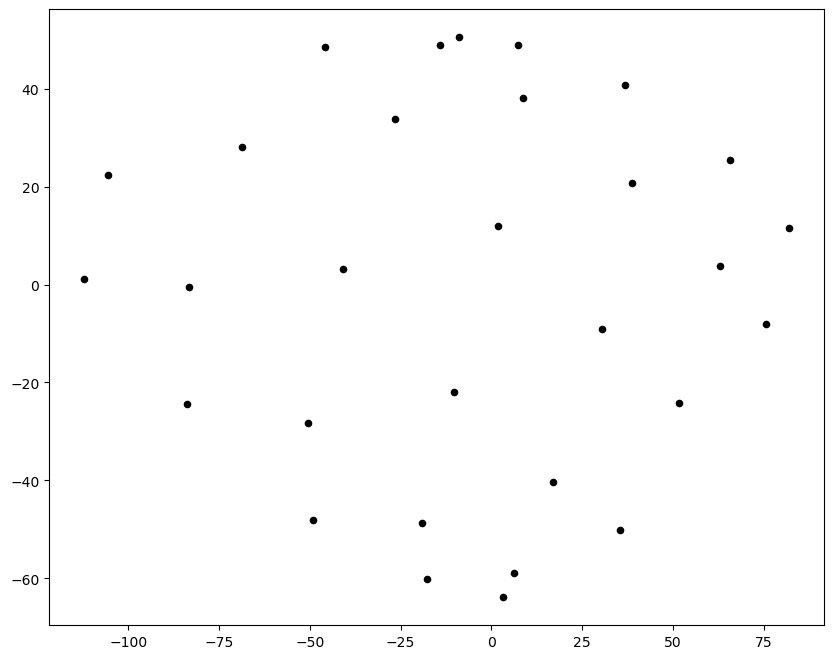

In [161]:
# Create a Sammon map
# A Sammon map is a type of nonlinear mapping technique used for dimensionality reduction and visualization of high-dimensional data. 
# It aims to preserve the pairwise distances between data points in the original high-dimensional space when projecting them onto a lower-dimensional space, typically two or three dimensions. 
# The goal is to create a visual representation that reflects the structure and relationships present in the original data.
weights = som.get_weights().reshape(-1, X.shape[1])
y, E = sammon.sammon(weights, 2, display=0)

# Plot Sammon map nodes: “Take each SOM node and place it in a 2D embedding space, then draw one black dot for each node.""
plt.figure(figsize=(10,8))
plt.scatter(y[:,0], y[:,1], s=20, c='black', marker='o')

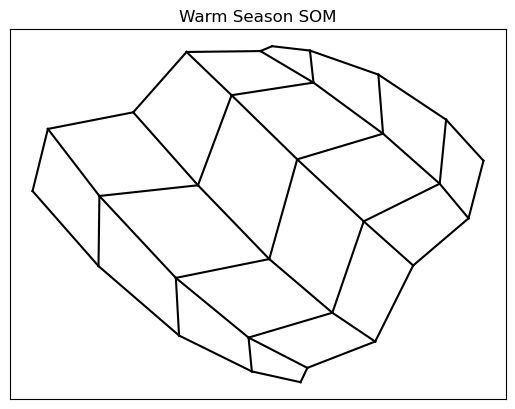

In [162]:
# Add lines between nodes
node_positions = np.reshape(y, (n_rows, n_cols, 2))
len_x, len_y, len_z = node_positions.shape

# add vertical lines
for i in range(len_x-1):
    for j in range(len_y):
        plt.plot(node_positions[i:i+2,j,0],node_positions[i:i+2,j,1],c='black')

# add horizontal lines
for i in range(len_x):
    for j in range(len_y-1):
        plt.plot(node_positions[i,j:j+2,0],node_positions[i,j:j+2,1],c='black')  

plt.xticks([])
plt.yticks([])
plt.title("Warm Season SOM", fontsize=12)
plt.show()

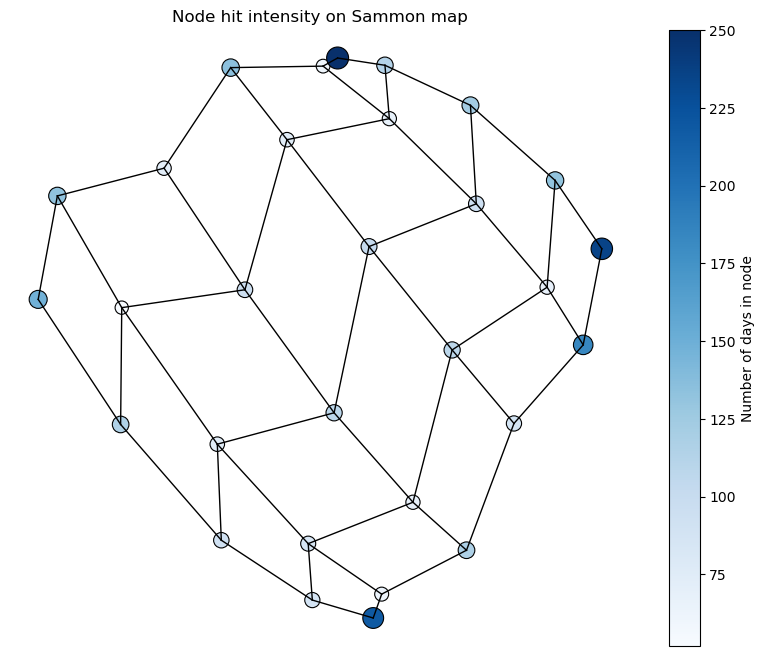

In [163]:
# node counts from  assignments
node_counts = (
    df_som["node"]
    .value_counts()
    .reindex(np.arange(n_rows * n_cols), fill_value=0)
    .to_numpy()
)

# reshape for plotting: (n_rows, n_cols, 2)
node_positions = y.reshape(n_rows, n_cols, 2)

# plot the Sammon embedding
fig, ax = plt.subplots(figsize=(10, 8))

# draw lines between nodes to show SOM topology
for i in range(n_rows - 1):
    for j in range(n_cols):
        ax.plot(
            node_positions[i:i+2, j, 0],
            node_positions[i:i+2, j, 1],
            c="black",
            linewidth=1
        )

for i in range(n_rows):
    for j in range(n_cols - 1):
        ax.plot(
            node_positions[i, j:j+2, 0],
            node_positions[i, j:j+2, 1],
            c="black",
            linewidth=1
        )

# flatten node positions for a single scatter call
flat_positions = node_positions.reshape(-1, 2)
flat_sizes = 50 + 200 * (node_counts / node_counts.max())

sc = ax.scatter(
    flat_positions[:, 0],
    flat_positions[:, 1],
    s=flat_sizes,
    c=node_counts,
    cmap="Blues",
    edgecolors="black",
    linewidths=0.8
)
fig.colorbar(sc, ax=ax, label="Number of days in node")
ax.set_title("Node hit intensity on Sammon map")
ax.set_axis_off()
plt.show()

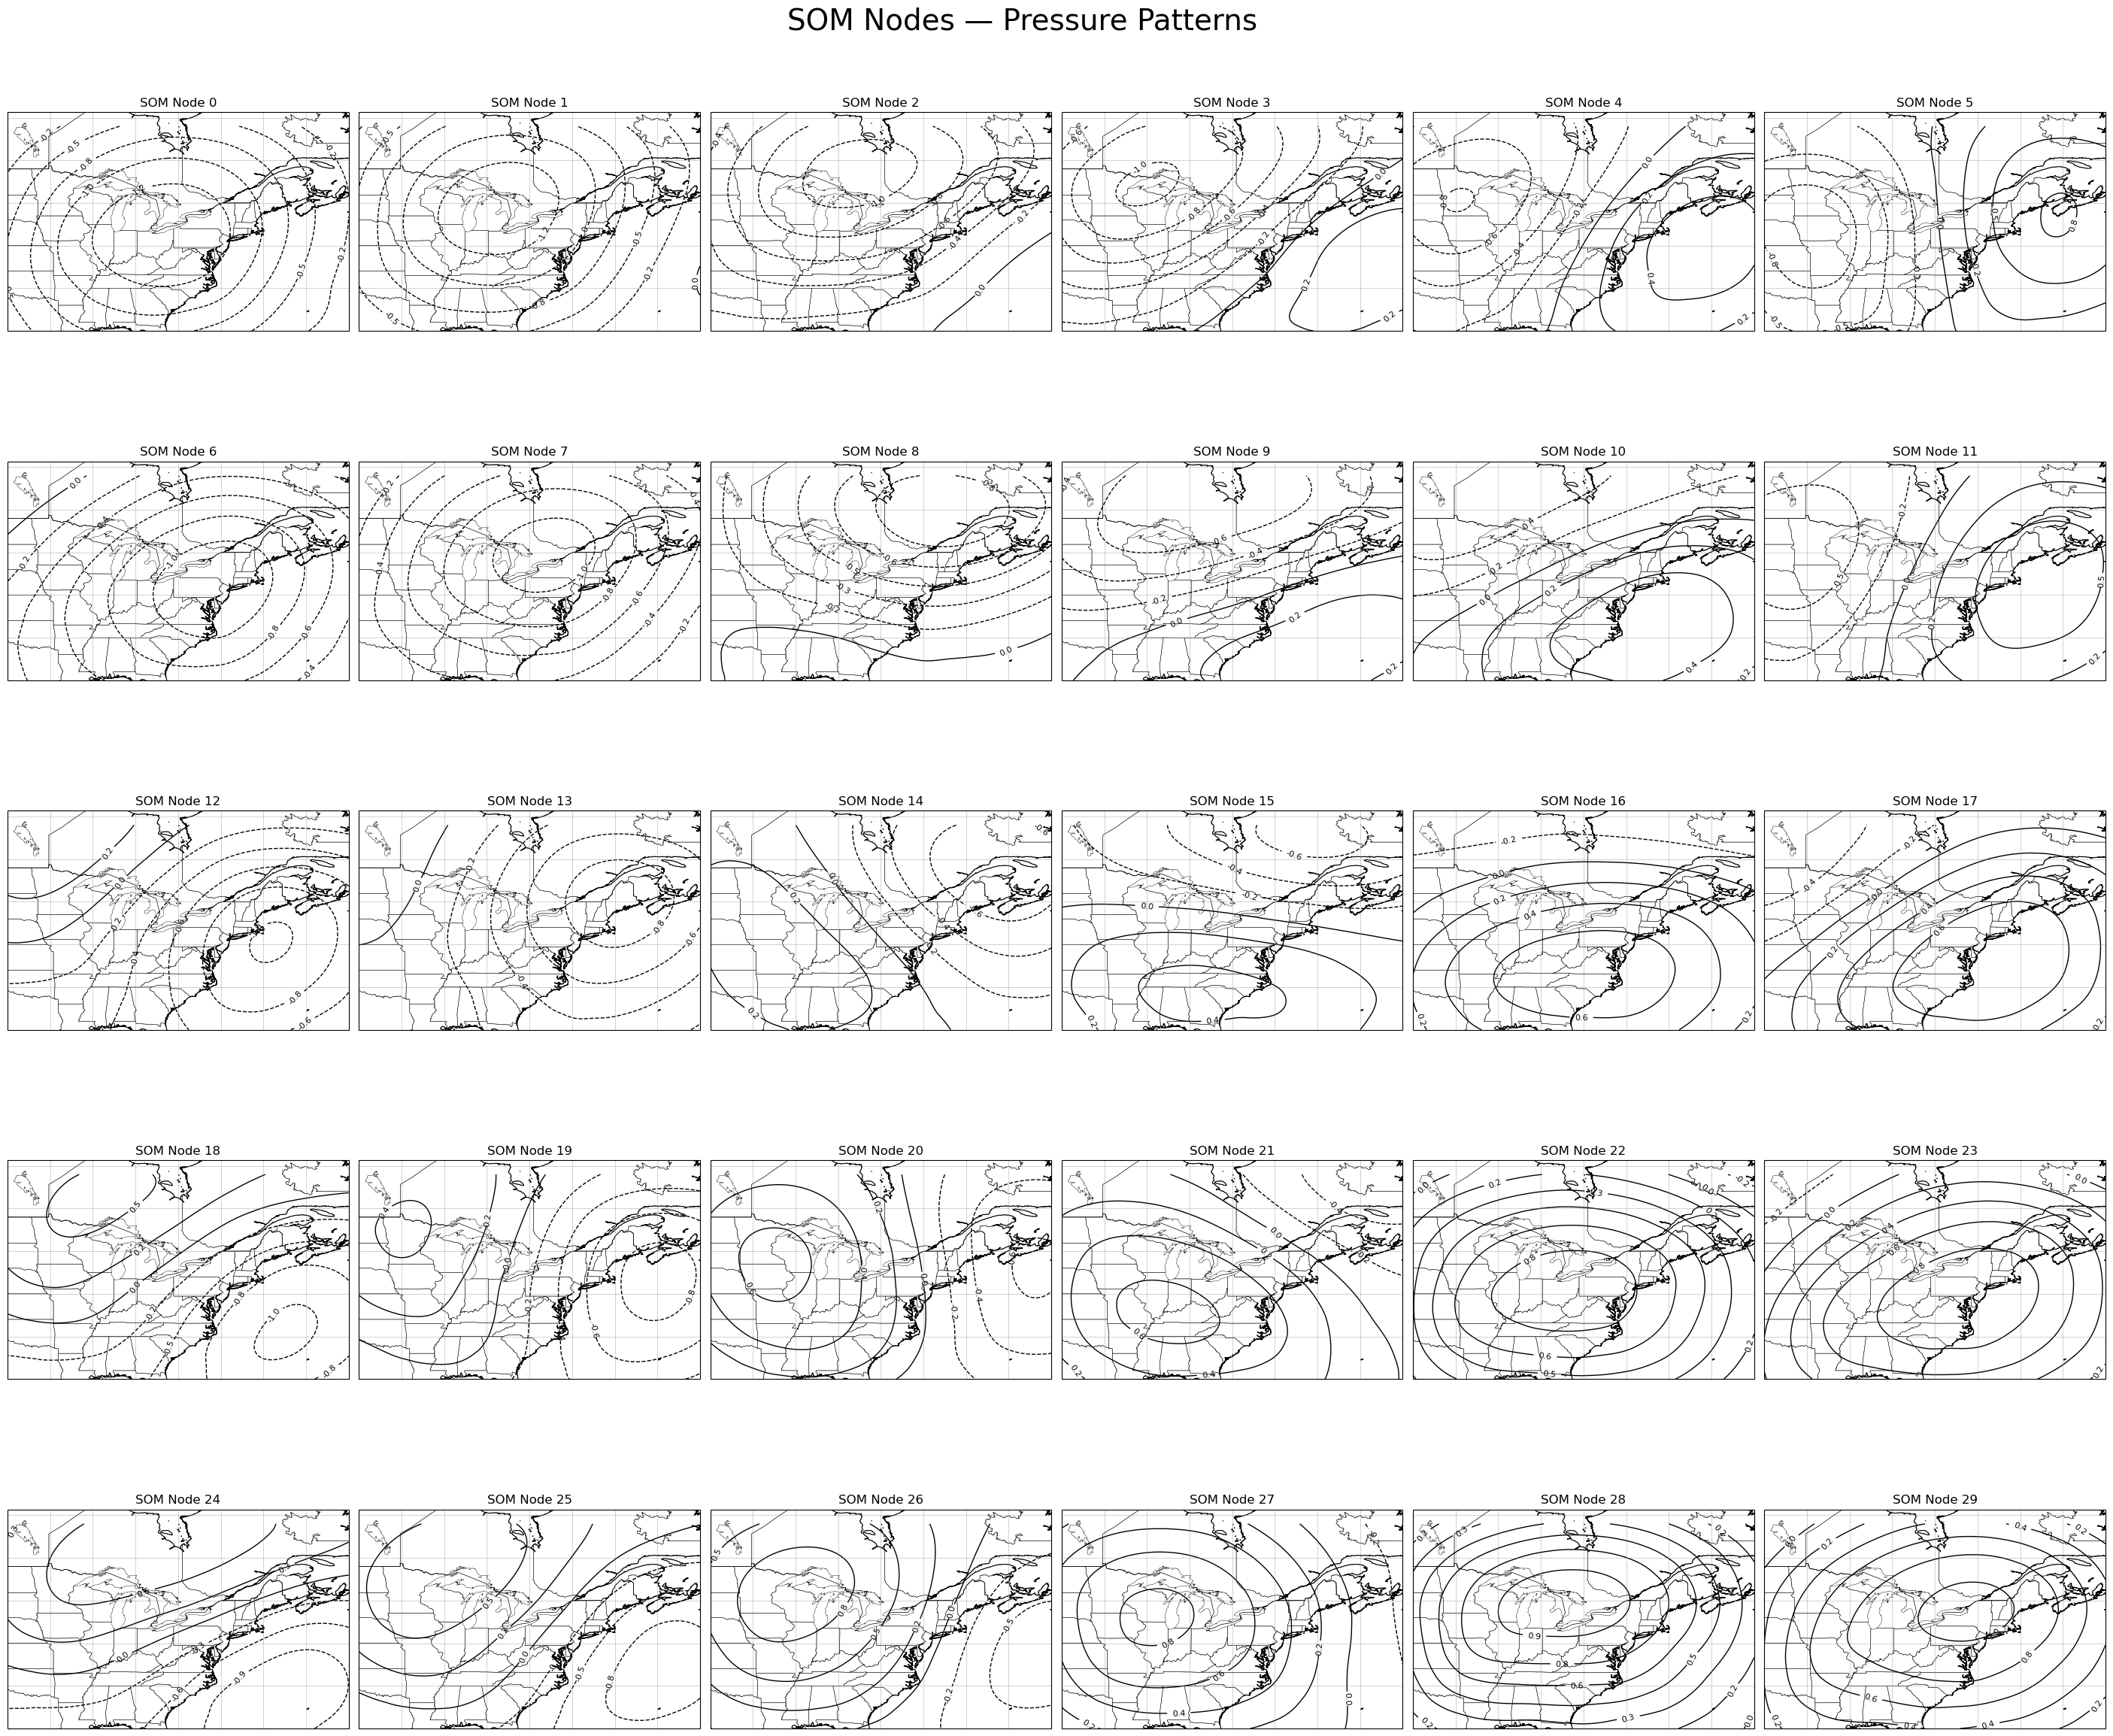

In [171]:
#Visualize the Meterological patterns for each SOM node
lats = ds['latitude'].values
lons = ds['longitude'].values

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6 * n_cols, 6 * n_rows),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = np.array(axes).flatten()

for i, ax in enumerate(axes[:len(som_centers)]):
    
    # reshape: (variables, lat, lon)
    cluster_map = som_centers[i].reshape(1, len(lats), len(lons))
    
    # --- Pressure (z-score) ---
    pressure_contours = ax.contour(
        lons,
        lats,
        cluster_map[0],
        levels=6,
        colors='black',
        linewidths=1
    )
    
    ax.clabel(
        pressure_contours,
        inline=True,
        fontsize=8,
        fmt="%.1f"
    )
    
    # map features
    ax.coastlines(resolution='10m', color='black', linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth=0.3)
    ax.set_title(f"SOM Node {i}", fontsize=12)
    ax.set_extent([lons.min(), lons.max(), lats.min(), lats.max()])
    ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5)

plt.subplots_adjust(wspace=0.03, hspace=0.03)
plt.suptitle('SOM Nodes — Pressure Patterns', fontsize=28, y=.9)

plt.show()

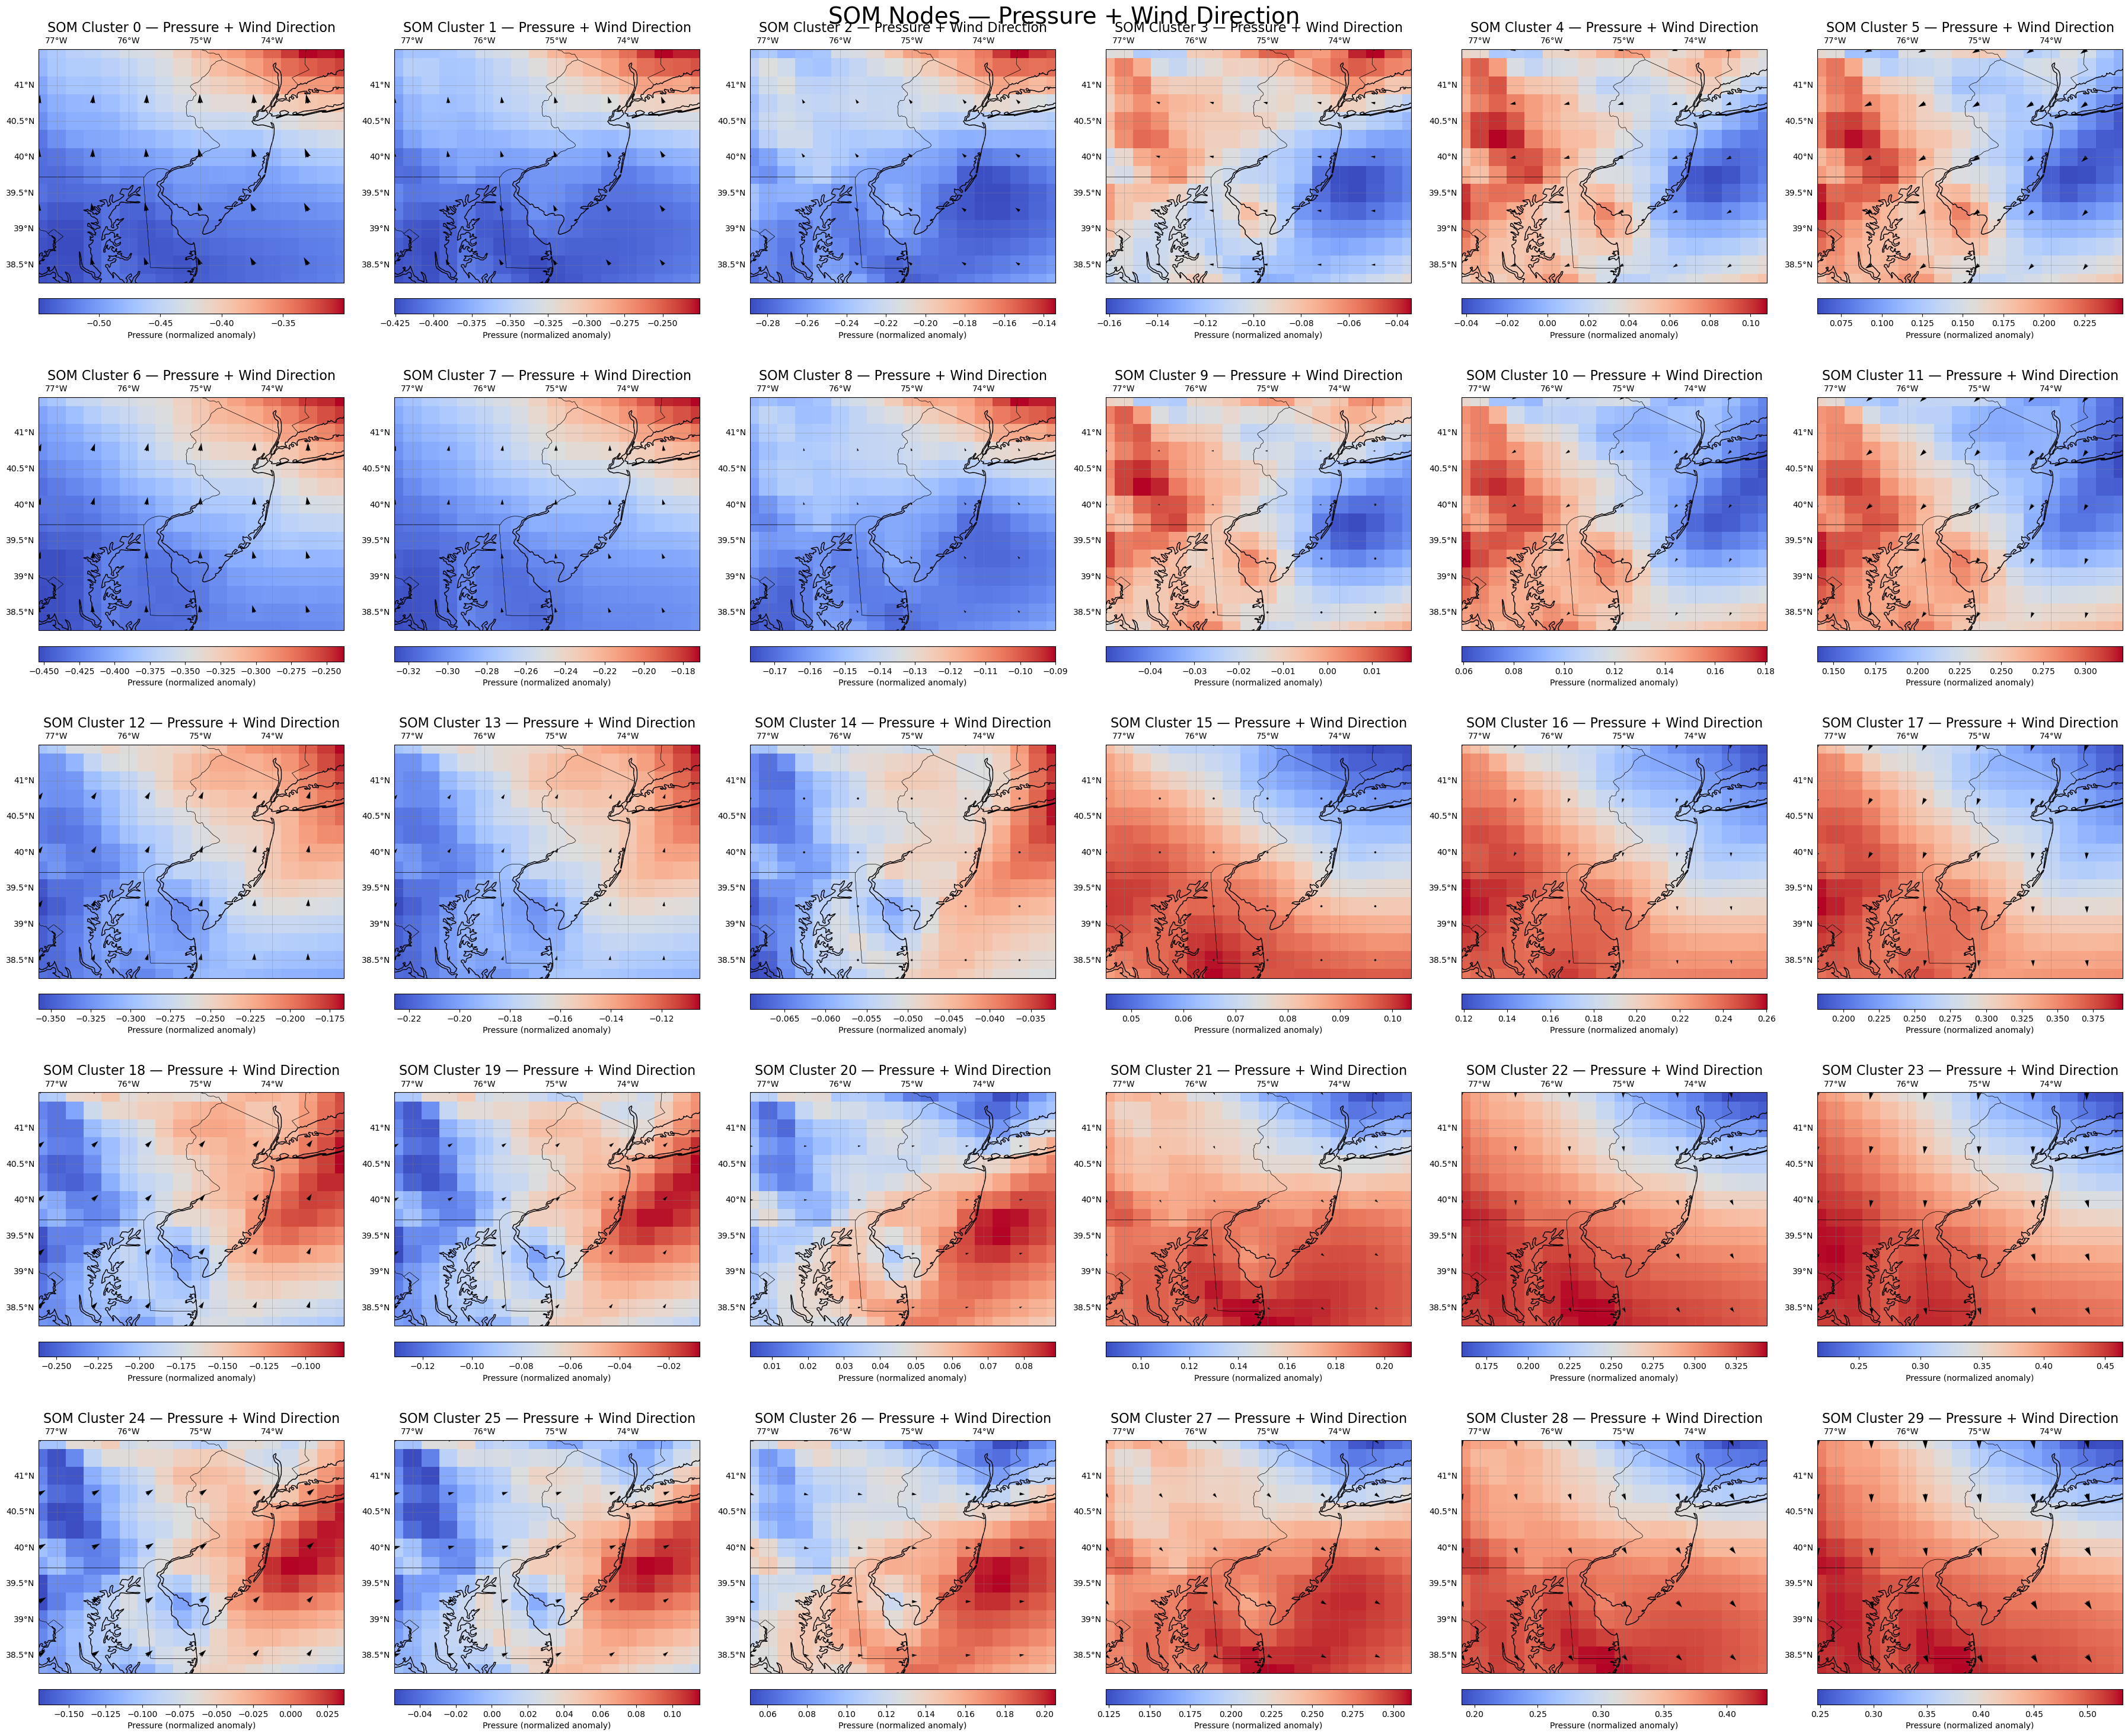

In [86]:
# Visualizing Pressure and Wind Direction
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6 * n_cols, 6 * n_rows),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = axes.flatten()

for i, ax in enumerate(axes[:len(som_centers)]):

    # SOM variable order:
    cluster_map = som_centers[i].reshape(3,len(lats),len(lons))

    # Extract variables
    SP = cluster_map[0]
    U10 = cluster_map[1]
    V10 = cluster_map[2]

    # Pressure
    im = ax.pcolormesh(lons, lats, SP, cmap='coolwarm', transform=ccrs.PlateCarree())

    # Wind Speed
    skip = (slice(None, None, 3), slice(None, None, 3))  # thin arrows
    ax.quiver(
        lons[skip[1]], lats[skip[0]],
        U10[skip], V10[skip],
        scale=20, color='black', transform=ccrs.PlateCarree()
    )

    # Map features

    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth=0.3)
    ax.set_extent([lons.min(), lons.max(), lats.min(), lats.max()])

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5)
    gl.top_labels = True
    gl.bottom_labels = False
    gl.left_labels = True
    gl.right_labels = False

    # Title
    ax.set_title( f"SOM Cluster {i} — Pressure + Wind Direction", fontsize=16)

    # Pressure colorbar
    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.05)
    cbar.set_label("Pressure (normalized anomaly)")

plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.suptitle( "SOM Nodes — Pressure + Wind Direction",fontsize=28)
plt.tight_layout()
plt.show()

Identify Camden's Warmest Days

In [172]:
ds = load_variable("temp")

print(ds)               # full structure
print(ds.variables)     # variables
print(ds.dims)          # dimensions
print(ds.attrs)         # metadata# Select nearest grid cell AND variable

<xarray.Dataset> Size: 190MB
Dimensions:     (valid_time: 184104, latitude: 14, longitude: 18)
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 1MB 2004-01-01 ... 2024-12-31T23:...
  * latitude    (latitude) float64 112B 41.5 41.25 41.0 ... 38.75 38.5 38.25
  * longitude   (longitude) float64 144B -77.25 -77.0 -76.75 ... -73.25 -73.0
    expver      (valid_time) <U4 3MB dask.array<chunksize=(8784,), meta=np.ndarray>
Data variables:
    t2m         (valid_time, latitude, longitude) float32 186MB dask.array<chunksize=(8784, 14, 18), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-30T10:57 GRIB to CDM+CF via cfgrib-0.9.1...
Frozen({'t2m': <xarray.Variable (valid_time: 184104, lati

In [173]:
camden_temp = ds["t2m"].sel(
    latitude=camden_lat,
    longitude=camden_lon,
    method="nearest"
)

# Daily mean
camden_temp_daily = camden_temp.resample(valid_time="1D").max()

# Convert to DataFrame
df_camden = camden_temp_daily.to_dataframe(name="temp")

print(df_camden.head())

            number  latitude  longitude        temp
valid_time                                         
2004-01-01       0      40.0      -75.0  281.487061
2004-01-02       0      40.0      -75.0  281.998291
2004-01-03       0      40.0      -75.0  286.991211
2004-01-04       0      40.0      -75.0  285.699219
2004-01-05       0      40.0      -75.0  279.808838


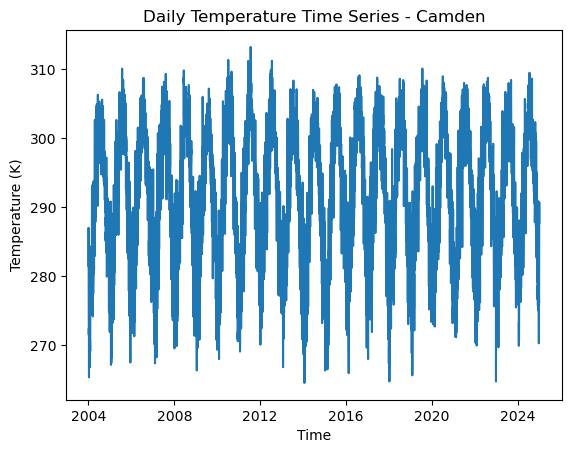

In [174]:
plt.figure()
plt.plot(df_camden.index, df_camden["temp"])
plt.xlabel("Time")
plt.ylabel("Temperature (K)")
plt.title("Daily Temperature Time Series - Camden")
plt.show()

In [175]:
# Extreme threshold (95th percentile)
threshold = df_camden["temp"].quantile(0.95) #This does not follow NJDEP's definition of extreme heat days, which is based on the a daily maximum temperature for a given location and time as 90 degrees or more
extreme_days = df_camden[df_camden["temp"] >= threshold]

In [176]:
print(threshold)
print(extreme_days)
print(len(extreme_days))

305.4949951171875
            number  latitude  longitude        temp
valid_time                                         
2004-06-09       0      40.0      -75.0  306.310791
2004-08-20       0      40.0      -75.0  305.602539
2005-06-08       0      40.0      -75.0  306.384766
2005-06-14       0      40.0      -75.0  306.706299
2005-07-10       0      40.0      -75.0  305.989014
...            ...       ...        ...         ...
2024-07-31       0      40.0      -75.0  305.593262
2024-08-01       0      40.0      -75.0  307.949463
2024-08-02       0      40.0      -75.0  307.369385
2024-08-05       0      40.0      -75.0  305.530518
2024-08-28       0      40.0      -75.0  308.658691

[384 rows x 4 columns]
384


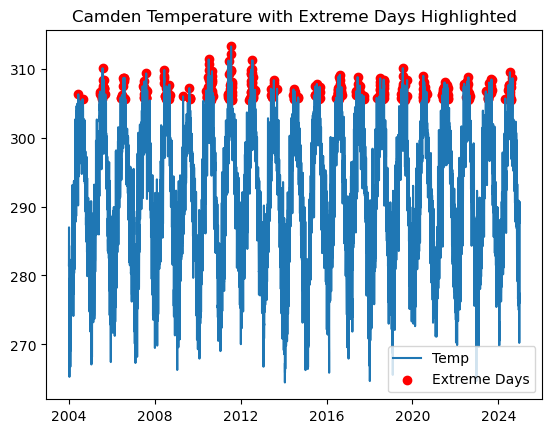

In [177]:
# Plot with extremes highlighted
plt.figure()
plt.plot(df_camden.index, df_camden["temp"], label="Temp")
plt.scatter(extreme_days.index, extreme_days["temp"], color="red", label="Extreme Days")
plt.legend()
plt.title("Camden Temperature with Extreme Days Highlighted")
plt.show()

In [178]:
# Match the extreme days to their SOM nodes
# Get the dates of the extreme days
extreme_dates = pd.to_datetime(extreme_days.index).normalize()

# Keep only SOM days that are extreme days
extreme_som = df_som[df_som.index.normalize().isin(extreme_dates)]

print("\nExtreme days with SOM nodes:")
print(extreme_som.head())

print("\nNumber of extreme days matched to SOM:")
print(len(extreme_som))


Extreme days with SOM nodes:
            node
time            
2004-06-09    22
2004-08-20     3
2005-06-08    15
2005-06-14     5
2005-07-10    24

Number of extreme days matched to SOM:
381


In [179]:
#Identify the missing days
som_dates = df_som.index.normalize()
missing = set(extreme_dates) - set(som_dates)
print(len(missing))
print(sorted(missing)[:10])

3
[Timestamp('2009-04-26 00:00:00'), Timestamp('2019-10-02 00:00:00'), Timestamp('2024-04-29 00:00:00')]


In [180]:
# Total days in the dataset
total_days = len(df_som)

# Count how many extreme days were assigned to each node
extreme_node_counts = extreme_som["node"].value_counts()

# Make sure EVERY node is represented, including nodes with 0
n_nodes = n_rows * n_cols

extreme_node_counts = extreme_node_counts.reindex(
    range(n_nodes),
    fill_value=0
)

# Days per node
node_dates = (
    df_som
    .groupby('node') 
    .apply(lambda x: x.index.date, include_groups=False) #x is a small DataFrame of only that cluster \ x.index = all timestamps in that cluster \.date removes the hour
)
# compute unique day counts,
days_per_node = (
    df_som
    .assign(date=df_som.index.date)
    .groupby('node')['date']
    .nunique()
)

# Percent of time
percent = (days_per_node / total_days) * 100

# Percent of extreme days
extreme_percent = (extreme_node_counts / len(extreme_som)) * 100

# Combine into one table
node_summary = pd.DataFrame({
    "Days": days_per_node,
    "Percent": percent.round(2),
    "Extreme Days": extreme_node_counts,
    "Extreme Day": extreme_percent.round(2)
})

print(node_summary)

      Days  Percent  Extreme Days  Extreme Day
node                                          
0      148     4.40             0         0.00
1      133     3.95             2         0.52
2       72     2.14             4         1.05
3      135     4.01            15         3.94
4       60     1.78            11         2.89
5      250     7.43            14         3.67
6      116     3.45             1         0.26
7       52     1.54             2         0.52
8       95     2.82             8         2.10
9       74     2.20            10         2.62
10      68     2.02            15         3.94
11     113     3.36            15         3.94
12      92     2.73             3         0.79
13      74     2.20             5         1.31
14     108     3.21            11         2.89
15     102     3.03            13         3.41
16      95     2.82            20         5.25
17     123     3.65            34         8.92
18      87     2.58             4         1.05
19      84   

Text(0.5, 1.0, 'Distribution of Extreme Days Across SOM Nodes')

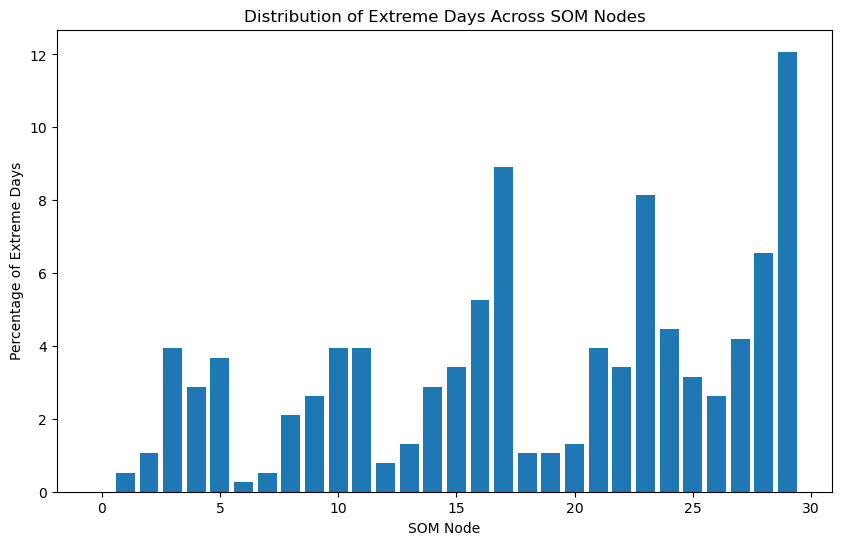

In [181]:
#Create a bar plot to visualize the number of extreme days assigned to each SOM node
plt.figure(figsize=(10, 6))
plt.bar(extreme_percent.index, extreme_percent.values)
plt.xlabel("SOM Node")
plt.ylabel("Percentage of Extreme Days")
plt.title("Distribution of Extreme Days Across SOM Nodes")

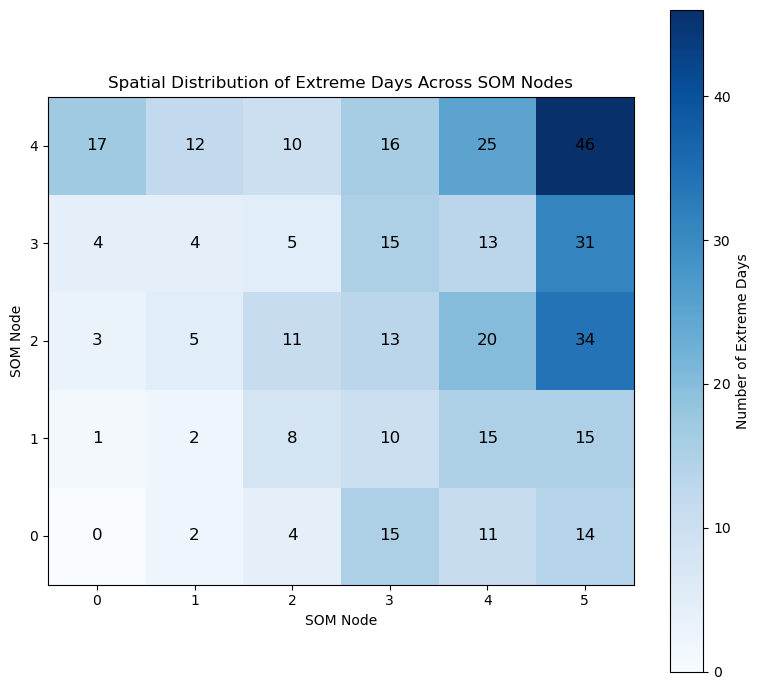

In [182]:
#Create a hit map to visualize the spatial distribution of extreme days across SOM nodes
plt.figure(figsize=(8, 7))
plt.imshow(extreme_node_counts.values.reshape(n_rows, n_cols), origin='lower', cmap='Blues', interpolation='nearest')
plt.colorbar(label='Number of Extreme Days')
plt.xlabel("SOM Node")
plt.ylabel("SOM Node")
plt.title("Spatial Distribution of Extreme Days Across SOM Nodes")

# Add count to each node
for i in range(n_rows):
    for j in range(n_cols):
        plt.text(
            j,
            i,
            extreme_node_counts.values[i * n_cols + j],
            ha="center",
            va="center",
            fontsize=12
        )

plt.tight_layout()
plt.show()